In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json 
import os

In [2]:
obj_id = 'AT2026brq'
z = 0.04586 ## estimate from simbad suspected host galaxy https://simbad.u-strasbg.fr/simbad/sim-coo?Coord=151.17226968482592%202.772519570258005&Radius.unit=arcsec&Radius=10
obj = pd.read_csv(f'../data/{obj_id}/detections.csv')
obj_forced = pd.read_csv(f'../data/{obj_id}/forced_photometry.csv')
obj = pd.concat([obj, obj_forced], ignore_index=True)
obj.head()

,oid,measurement_id,mjd,ra,dec,band,band_name,psfFlux,psfFluxErr,scienceFlux,...,procstatus,programid,ranr,rcid,rfid,scibckgnd,sciinpseeing,scisigpix,sharpnr,sigmagnr
0,313888627043074080,313888627043074080,61032.328003,151.172230,2.772517,1,g,1382.7146,131.31238,10071.7370,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,313888627043074080,313888627201409155,61032.328496,151.172268,2.772450,1,g,1206.7490,133.63110,11022.2295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,313888627043074080,313888627337199768,61032.328993,151.172252,2.772539,1,g,1092.9658,213.89166,12288.9540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,313888627043074080,313893021491921011,61033.277874,151.172253,2.772499,1,g,4270.9097,178.78746,16333.4590,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,313888627043074080,313893021628235863,61033.278369,151.172140,2.772418,1,g,3794.3481,175.38098,16123.1820,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
def flux2mag(flux, flux_err):
    mag = -2.5 * np.log10(flux) + 31.4 ## zero point according to https://dp1.lsst.io/tutorials/portal/103/portal-103-3.html
    mag_err = 2.5 / np.log(10) * flux_err / flux
    return mag, mag_err

mag, mag_err = flux2mag(obj['psfFlux'], obj['psfFluxErr'])

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
conv_obj = pd.DataFrame()
conv_obj['id'] = obj['oid']
conv_obj['mjd'] = obj['mjd']
conv_obj['mag'] = mag
conv_obj['magerr'] = mag_err
conv_obj['limiting_mag'] = obj['diffmaglim']
conv_obj['filter'] = obj['band_name']
conv_obj['instrument_name'] = 'LSST'
conv_obj['snr'] = obj['psfFlux'] / obj['psfFluxErr']
conv_obj['magsys'] = 'ab'
conv_obj['flux'] = obj['psfFlux']
conv_obj['flux_err'] = obj['psfFluxErr']
conv_obj['instrument_id'] = obj['visit']
conv_obj.dropna(subset=['mag'], inplace=True)
conv_obj.head()

,id,mjd,mag,mag_err,limiting_mag,filter,instrument_name,snr,magsys,flux,flux_err,instrument_id
0,313888627043074080,61032.328003,23.548169,0.103109,NaN,g,LSST,10.529964,ab,1382.7146,131.31238,2025122200354
1,313888627043074080,61032.328496,23.695958,0.120231,NaN,g,LSST,9.030450,ab,1206.7490,133.63110,2025122200355
2,313888627043074080,61032.328993,23.803484,0.212477,NaN,g,LSST,5.109904,ab,1092.9658,213.89166,2025122200356
3,313888627043074080,61033.277874,22.323699,0.045451,NaN,g,LSST,23.888195,ab,4270.9097,178.78746,2025122300327
4,313888627043074080,61033.278369,22.452157,0.050185,NaN,g,LSST,21.634889,ab,3794.3481,175.38098,2025122300328


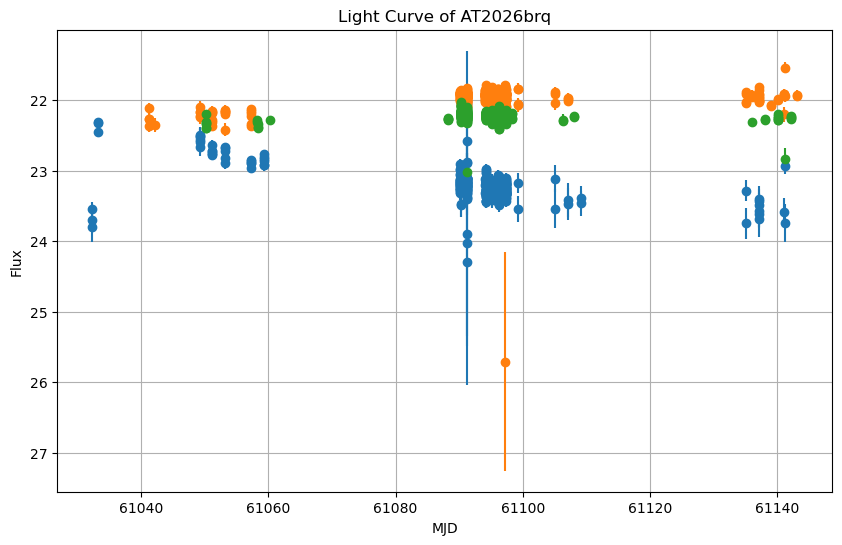

In [11]:
## plot the light curve using pandas and color by filter
plt.figure(figsize=(10,6))
for f in conv_obj['filter'].unique():
    if f not in ['g', 'r', 'i']:
        continue
    subset = conv_obj[conv_obj['filter'] == f]
    plt.errorbar(subset['mjd'], subset['mag'], yerr=subset['mag_err'], fmt='o', label=f)
plt.gca().invert_yaxis()
plt.xlabel('MJD')
plt.ylabel('Flux')
plt.title(f'Light Curve of {obj_id}')
plt.grid()
# plt.xlim(61032,61057)
# plt.ylim(24,20)
plt.show()

In [12]:
conv_obj.to_csv(f'../data/{obj_id}/{obj_id}_photometry.csv', index=False)